Pivoting to a hierarchical structure for a scene graph. This is motivated by the complexity of calculating GED for an arbitrary grpah - structuring it as a tree may yield better performance for similarity metric calculation.

# Setup

## Notebook Setup

Google Colab
- Google Colab secrets: add a Gemini API key as `GOOGLE_API_KEY`. May be pre-populated from a previous session.
    - Need to create an account for Gemini and grab a key there.

In [1]:
from google import genai
from PIL import Image
import json
import urllib.request
import cv2
import sys
from dotenv import load_dotenv
import os
from common.draw_class import Drawer

GOOGLE_COLAB = 'google.colab' in sys.modules

In [2]:
GEMINI_API_KEY = None
if GOOGLE_COLAB:
    from google.colab import userdata
    GEMINI_API_KEY = userdata.get('GOOGLE_API_KEY')
else:
    load_dotenv()
    GEMINI_API_KEY = os.environ.get('GOOGLE_API_KEY')

gemini_client = genai.Client(api_key=GEMINI_API_KEY)
gemini_model = "gemini-1.5-flash"

In [3]:
kitchen_portrait = Image.open("img/kitchen_portrait.jpg")

In [4]:
# load dictionary of classes
with open('common/classes/classes.json') as f:
    id_bank = json.load(f)

## Util

In [5]:
def response_to_json(res):
    """
    Takes the output of a model and returns the parsed result.

    May need to clean up the output if it is a code chunk.
    """
    if res.startswith("```json"):
        res = res[7:-4]
    
    try:
        return json.loads(res)
    except:
        raise ValueError(f"Could not parse JSON: {res}")

In [6]:
def generate_scene_graph(img, prompt, context=[]):
    contents = [img, prompt]

    if context:
        contents.extend(context)
    
    response = gemini_client.models.generate_content(
        model=gemini_model,
        contents=contents,
        config={
            "response_mime_type": "application/json"
        }
    ).text

    graph = response_to_json(response)
    return graph

In [7]:
def simple_print(node, level=0):
    tabs = '\t' * level
    print(f"{tabs}{node['name']} ({node['id']}) {node['predicate']}: {node['attributes']}")

    for child in node['children']:
        simple_print(child, level+1)

## Grab video frames

In [8]:
zipnerf_video_path = "img/zipnerf.mp4"

# check if video already exists
if not os.path.exists(zipnerf_video_path):
    # download from source
    print("Downloading video...")
    zipnerf_video_url = "https://jonbarron.info/zipnerf/img/teaser.mp4"
    urllib.request.urlretrieve(zipnerf_video_url, zipnerf_video_path)
    print(f"Video downloaded to {zipnerf_video_path}.")
else:
    print(f"Video already available locally at {zipnerf_video_path}.")

Video already available locally at img/zipnerf.mp4.


In [9]:
# read in and process
zipnerf_video = cv2.VideoCapture(zipnerf_video_path)
zipnerf_livingroom_time = [4, 10]
zipnerf_kitchen_time = [10, 12]

In [10]:
# from google.colab.patches import cv2_imshow

def extract_frames(video, start_time, spacing_seconds, num_frames):
    """
    Extracts frames from a video starting at a given time and spacing.

    Args:
    - start_time (int): The time in seconds to start extracting frames.
    - spacing_seconds (float): The time in seconds between each frame.
    - num_frames (int): The number of frames to extract.

    Returns:
    - List[PIL.Image]: The extracted frames.
    """
    fps = video.get(cv2.CAP_PROP_FPS)
    print(f"Frame rate: {fps} FPS")
    frame_count = int(video.get(cv2.CAP_PROP_FRAME_COUNT))
    print(f"Total frames: {frame_count}")

    start_frame = int(start_time * fps)
    spacing_frames = int(spacing_seconds * fps)
    cur_frame = start_frame
    video_frames = []

    for i in range(num_frames):
        cur_frame = start_frame + i * spacing_frames
        video.set(cv2.CAP_PROP_POS_FRAMES, cur_frame)
        success, image = video.read()
        if success:
            # filename = f"frame_{i}.jpg"
            # cv2.imwrite(filename, image)
            # print(f"Saved frame {filename}")

            image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            pil_image = Image.fromarray(image_rgb)
            video_frames.append(pil_image)
        else:
            print("Failed to retrieve frame.")
    
    return video_frames

In [11]:
sample_frames = extract_frames(zipnerf_video, zipnerf_kitchen_time[0], 0.1, 3)
shortvid_frames = extract_frames(zipnerf_video, zipnerf_kitchen_time[0] - 1, 0.05, 60)

Frame rate: 60.0 FPS
Total frames: 1920
Frame rate: 60.0 FPS
Total frames: 1920


# Try generating a hierarchical scene graph

In [12]:
prompt = """Return a scene graph for this image in a JSON format.
You should use a hierarchical format such that all objects are "in" or "on" the parent object.
You must adhere to the following rules:

1. Do not include any additional text.
2. Use this JSON format:
{
    "id": 1,
    "name": "category as a string",
    "bbox": [y_min, x_min, y_max, x_max],
    "attributes": ["string"],
    "predicate": "on",
    "children": [
        // same format as above
    ]
}
3. The scene graph should accurately represent the objects in the image and their relationships.
4. The predicate should be either "root", "on", or "in".
"""

In [13]:
kitchen_portrait_graph = generate_scene_graph(kitchen_portrait, prompt)
kitchen_portrait_graph

{'id': 1,
 'name': 'kitchen',
 'bbox': [0, 0, 999, 999],
 'attributes': ['full'],
 'predicate': 'root',
 'children': [{'id': 2,
   'name': 'cabinets',
   'bbox': [0, 0, 386, 999],
   'attributes': ['wooden', 'light brown'],
   'predicate': 'in',
   'children': [{'id': 3,
     'name': 'microwave',
     'bbox': [154, 187, 343, 574],
     'attributes': ['stainless steel', 'whirlpool'],
     'predicate': 'on',
     'children': []}]},
  {'id': 4,
   'name': 'countertop',
   'bbox': [386, 0, 699, 999],
   'attributes': ['dark gray', 'marble'],
   'predicate': 'in',
   'children': [{'id': 5,
     'name': 'toaster oven',
     'bbox': [446, 60, 537, 277],
     'attributes': ['black', 'breville'],
     'predicate': 'on',
     'children': []},
    {'id': 6,
     'name': 'cooktop',
     'bbox': [446, 277, 562, 627],
     'attributes': ['stainless steel', 'whirlpool'],
     'predicate': 'on',
     'children': [{'id': 7,
       'name': 'pan',
       'bbox': [519, 386, 580, 541],
       'attributes':

In [14]:
simple_print(kitchen_portrait_graph)

kitchen (1) root: ['full']
	cabinets (2) in: ['wooden', 'light brown']
		microwave (3) on: ['stainless steel', 'whirlpool']
	countertop (4) in: ['dark gray', 'marble']
		toaster oven (5) on: ['black', 'breville']
		cooktop (6) on: ['stainless steel', 'whirlpool']
			pan (7) on: ['black', 'round']
		oil bottles (8) on: ['yellow', 'glass']
		water pitcher (9) on: ['clear', 'plastic']
		paper towels (10) on: ['white', 'roll']
		bowl (11) on: ['stainless steel', 'round']
	oven (12) on: ['black', 'whirlpool', 'stainless steel']
	dishwasher (13) on: ['stainless steel', 'whirlpool']
	drawers (14) in: ['wooden', 'light brown']


In [15]:
# process the tree
objects = {}
relationships = {}

def traverse(node, parent=None):
    if not node:
        return
    
    # add object
    objects[node["id"]] = {
        "name": node["name"],
        "bbox": node["bbox"],
    }

    # add edge to parent
    if parent and node["predicate"] != "root":
        relationships[(node["id"], parent["id"])] = node["predicate"]

    for child in node['children']:
        traverse(child, node)

traverse(kitchen_portrait_graph)

print(objects)
print(relationships)

{1: {'name': 'kitchen', 'bbox': [0, 0, 999, 999]}, 2: {'name': 'cabinets', 'bbox': [0, 0, 386, 999]}, 3: {'name': 'microwave', 'bbox': [154, 187, 343, 574]}, 4: {'name': 'countertop', 'bbox': [386, 0, 699, 999]}, 5: {'name': 'toaster oven', 'bbox': [446, 60, 537, 277]}, 6: {'name': 'cooktop', 'bbox': [446, 277, 562, 627]}, 7: {'name': 'pan', 'bbox': [519, 386, 580, 541]}, 8: {'name': 'oil bottles', 'bbox': [484, 617, 590, 728]}, 9: {'name': 'water pitcher', 'bbox': [490, 728, 632, 864]}, 10: {'name': 'paper towels', 'bbox': [462, 856, 645, 980]}, 11: {'name': 'bowl', 'bbox': [600, 870, 691, 999]}, 12: {'name': 'oven', 'bbox': [557, 119, 963, 455]}, 13: {'name': 'dishwasher', 'bbox': [682, 455, 999, 938]}, 14: {'name': 'drawers', 'bbox': [557, 0, 948, 119]}}
{(2, 1): 'in', (3, 2): 'on', (4, 1): 'in', (5, 4): 'on', (6, 4): 'on', (7, 6): 'on', (8, 4): 'on', (9, 4): 'on', (10, 4): 'on', (11, 4): 'on', (12, 1): 'on', (13, 1): 'on', (14, 1): 'in'}


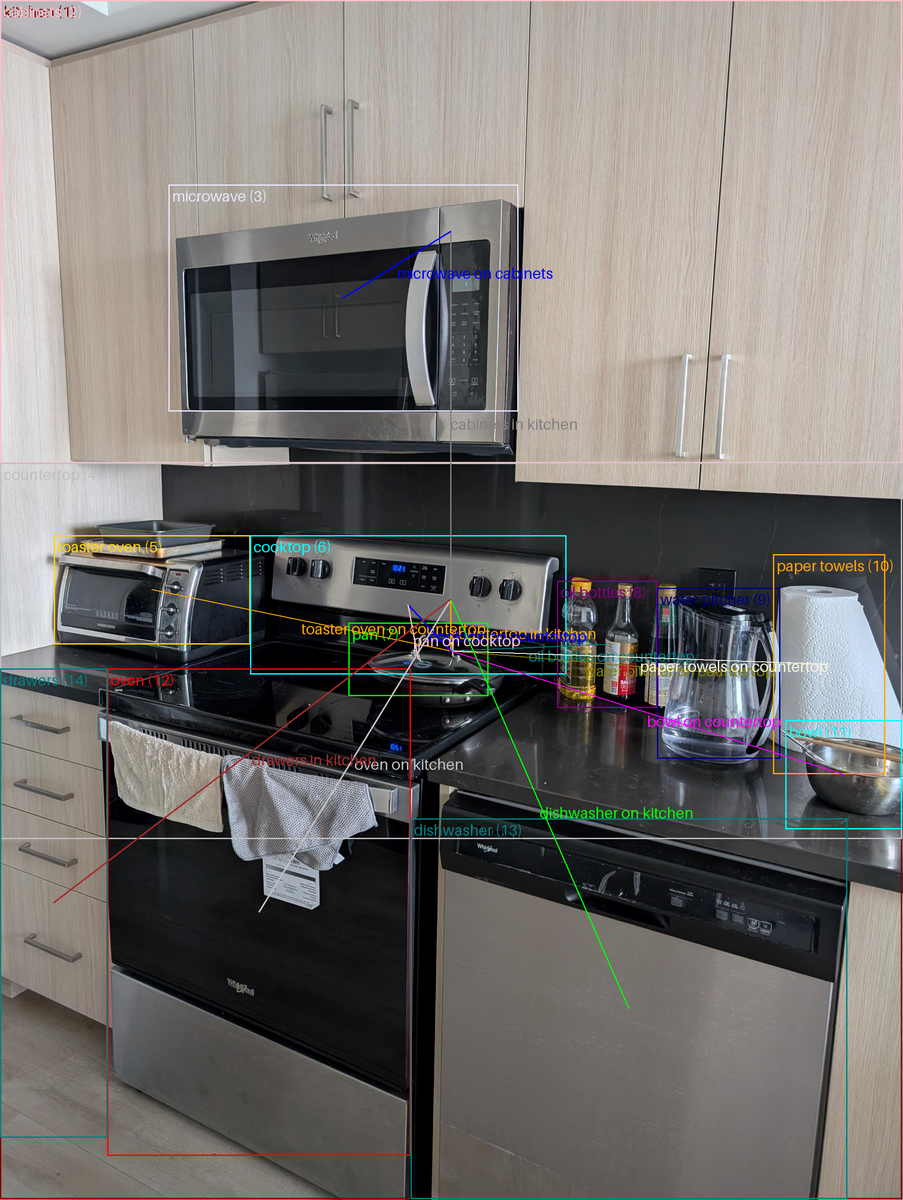

In [16]:
draw = Drawer(kitchen_portrait)

draw.add_objects(objects)
draw.add_relationships(relationships)

draw.draw()
draw.show()

# Tree Edit Distance

In [26]:
from zss import simple_distance, Node
from collections import defaultdict

In [40]:
sample_graphs = []
for frame in sample_frames:
    sample_graph = generate_scene_graph(frame, prompt)
    sample_graphs.append(sample_graph)
    simple_print(sample_graph)

room (1) root: ['indoor']
	kitchen_counter (2) in: ['brown']
		coffee_maker (3) on: ['black']
		paper_towel_holder (4) on: ['white']
		mug (5) on: ['yellow']
	dining_table (6) in: ['brown', 'wooden']
		plate (7) on: ['white']
		cup (8) on: ['pink']
		cup (9) on: ['blue']
		water_bottle (10) on: ['blue']
		chair (11) on: ['wooden', 'brown']
		chair (12) on: ['wooden', 'brown']
		chair (13) on: ['wooden', 'brown']
	window (14) in: ['white']
		blinds (15) on: ['white']
		plants (16) in: ['green']
	bookshelf (17) in: ['brown', 'wooden']
	picture (18) in: ['brown']
room (1) root: ['indoor']
	kitchen_counter (2) in: ['brown', 'shiny']
		cutting_board (3) on: ['white']
	dining_table (4) in: ['wooden', 'round']
		chair (5) on: ['wooden']
		chair (6) on: ['wooden']
		cup (7) on: ['red']
		plate (8) on: ['white']
	window (9) in: ['white']
		blinds (10) on: ['white']
		garden (11) in: ['outdoor']
			chair (12) in: ['black']
			chair (13) in: ['black']
	shelf (14) in: ['wooden']
	step_stool (15) i

In [41]:
# create trees

def make_node(obj):
    info = {
        "id": obj["id"],
        "name": obj["name"],
        "bbox": obj["bbox"],
        "predicate": obj["predicate"],
    }

    label = json.dumps(info)

    node = Node(label)

    for child in obj['children']:
        child_node = make_node(child)
        node.addkid(child_node)
    
    return node

sample_trees = []
for graph in sample_graphs:
    sample_trees.append(make_node(graph))

In [42]:
# define distance

def iou(bb1, bb2):
    x11, y11, x12, y12 = bb1
    x21, y21, x22, y22 = bb2
    x_overlap = max(0, min(x12, x22) - max(x11, x21))
    y_overlap = max(0, min(y12, y22) - max(y11, y21))
    intersection = x_overlap * y_overlap
    union = (x12 - x11) * (y12 - y11) + (x22 - x21) * (y22 - y21) - intersection
    iou = intersection / union
    return iou

def label_dist(a, b):
    a = json.loads(a) if a else defaultdict(lambda: '')
    b = json.loads(b) if b else defaultdict(lambda: '')

    cost = 0

    for k in ['id', 'name', 'predicate']:
        if a[k] != b[k]:
            cost += 1
    
    if not a['bbox'] or not b['bbox']:
        cost += 1
    else:
        iou_score = iou(a['bbox'], b['bbox'])
        if iou_score < 0.5:
            cost += 1
    
    return cost

In [43]:
print(simple_distance(sample_trees[0], sample_trees[1], label_dist=label_dist))
print(simple_distance(sample_trees[1], sample_trees[2], label_dist=label_dist))

52.0
40.0
